# **EDA Handwritten Digit Recognition (MNIST)**

The **MNIST** dataset is used to solve the handwritten digit recognition problem.
It contains 70,000 grayscale images of handwritten digits (0–9), split into:

- **Training set:** 60,000 images
- **Test set:** 10,000 images

Each image is 28×28 pixels with pixel values in the range 0–255.

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist

**1.Load the Dataset**

In [11]:
# Load the training dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


**2.Understand the Dataset: Understand the shape, size and nature of the images and labels.**

In [12]:
# Normalize pixel values to [0, 1] and cast labels to int
X_train = X_train / 255.0
y_train = y_train.astype('int')

X_test = X_test / 255.0
y_test = y_test.astype('int')

# Check for missing values
print("Missing values in X_train dataset:", np.isnan(X_train).any())
print("Missing values in X_test dataset:", np.isnan(X_test).any())
print()

# Display shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

# Number of unique classes
num_classes = len(np.unique(y_train))
print()
print("Number of classes:", num_classes)
print("Classes present:  ", np.unique(y_train))

Missing values in X_train dataset: False
Missing values in X_test dataset: False

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)

Number of classes: 10
Classes present:   [0 1 2 3 4 5 6 7 8 9]


**3.Visualize the Dataset**

In [13]:
def display_sample_images(pixels, labels):
    """
    Display a 5x5 grid of sample images from the dataset with their corresponding labels.

    Parameters
    ----------
    pixels : array-like
        Array of image data with shape (n_samples, height, width)
    labels : array-like
        Array of label indices corresponding to the images
    label_dict : dict
        Dictionary mapping label indices to their text descriptions

    Returns
    -------
    None
        Displays the plot using matplotlib
    """
    plt.figure(figsize=(10, 8))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(pixels[i], cmap='gray')
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

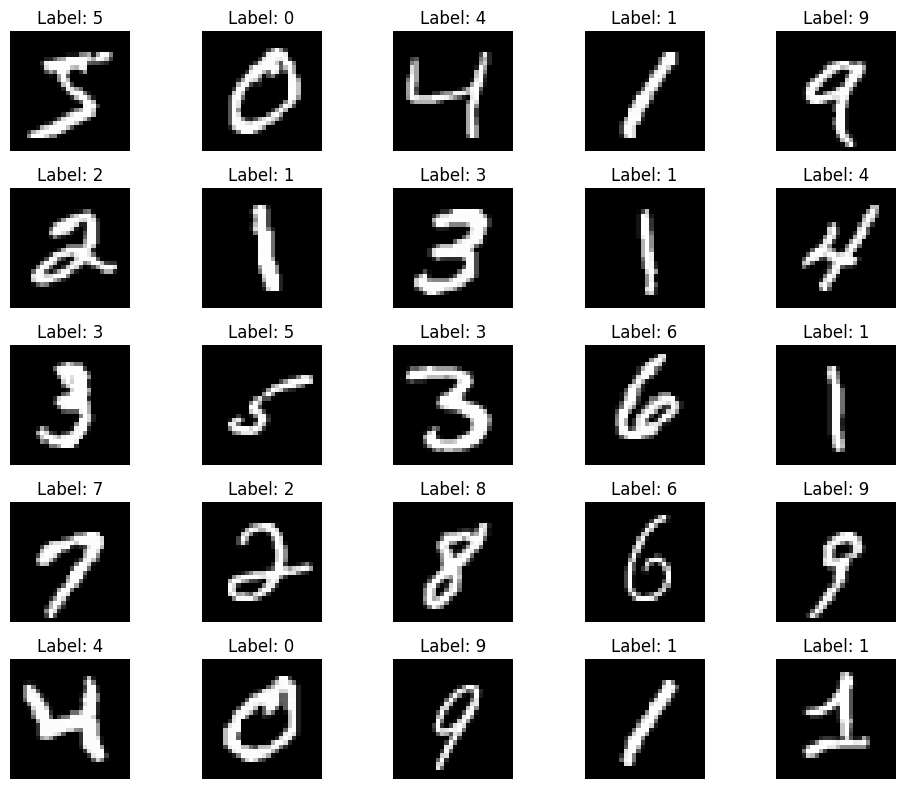

In [14]:
display_sample_images(X_train, y_train)

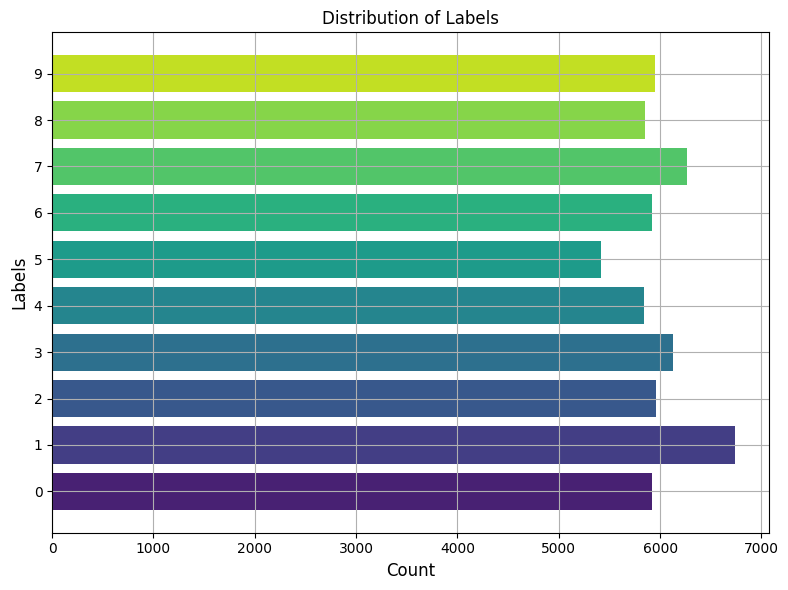

In [15]:
def visualize_label_distribution(labels):
    """
    Create a horizontal bar chart showing the distribution of labels in the dataset.

    Parameters
    ----------
    labels : array-like
        Array of label indices representing the class of each sample

    Returns
    -------
    None
        Displays the plot using matplotlib
    """
    unique_labels, label_counts = np.unique(labels, return_counts=True)

    plt.figure(figsize=(8, 6))
    plt.barh(unique_labels, label_counts, color=sns.color_palette('viridis', len(unique_labels)))
    plt.title('Distribution of Labels')
    plt.ylabel('Labels', fontsize=12)
    plt.xlabel('Count', fontsize=12)
    plt.yticks(unique_labels, unique_labels)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Label distribution in training sets
visualize_label_distribution(y_train)

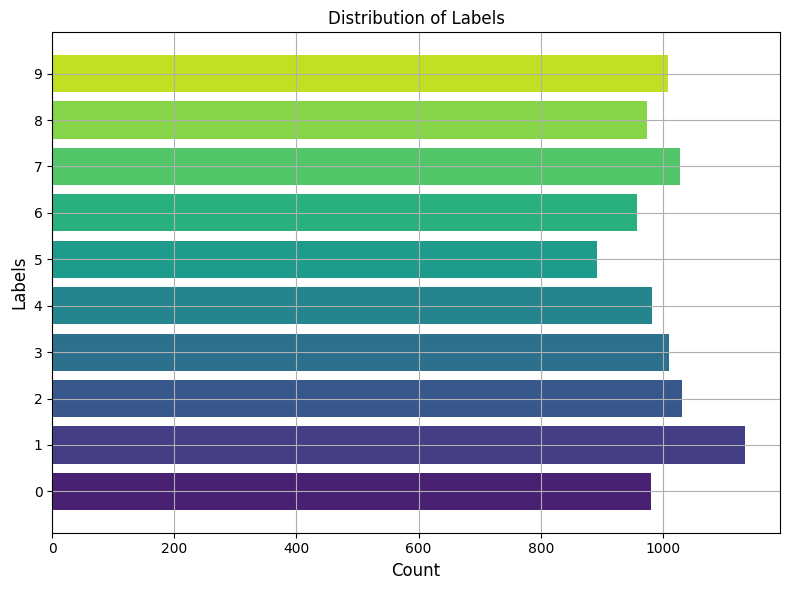

In [16]:
# Label distribution in test sets
visualize_label_distribution(y_test)

**4.Mean Images for Each Handwritten Digit Class**

Let's create heatmaps for each class in the training set. For example, we can take all the samples of class "0", add them to the same image, and calculate the probabilities that each pixel will be colored in the case of class "0".

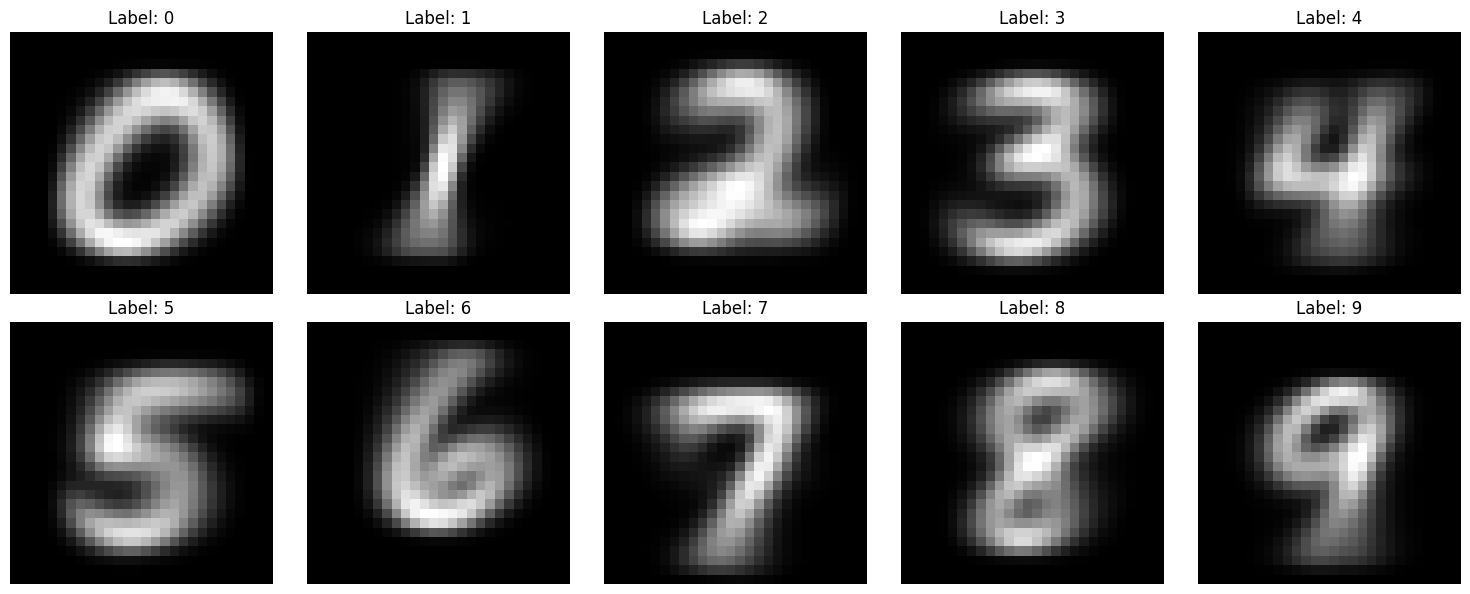

In [17]:
def calculate_mean_images(images, labels):
    """
    Calculate the mean image for each class in the dataset.

    Parameters
    ----------
    images : numpy.ndarray
        Array of image data with shape (n_samples, height, width)
    labels : numpy.ndarray
        Array of label indices with shape (n_samples,)

    Returns
    -------
    numpy.ndarray
        Array of mean images with shape (10, height, width)
    """
    mean_images = np.zeros((10, 28, 28), dtype=np.float32)
    for label in range(10):
        sample_image_idx = np.where(labels == label)[0]
        mean_images[label] = np.mean(images[sample_image_idx], axis=0)
    return mean_images


def plot_mean_images(mean_images):
    """
    Create a grid plot of mean images for each class with their corresponding labels.

    Parameters
    ----------
    mean_images : numpy.ndarray
        Array of mean images with shape (10, height, width)

    Returns
    -------
    None
        Displays the plot using matplotlib
    """
    plt.figure(figsize=(15, 6))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.title(f'Label: {i}')
        plt.imshow(mean_images[i], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

mean_images = calculate_mean_images(X_train, y_train)
plot_mean_images(mean_images)

Looks like we are good with our heatmaps. At least visually we can identify each number from the output.

**5.Test Dataset Evaluation with RMSE-based Prediction**

We compare each test image with the mean image of each class using Root Mean Squared Error (RMSE). The class with the lowest RMSE is selected as the predicted label. This is a baseline method that requires no machine learning training.

To understand the performance of our non-machine learning model let's build a simple code that assigns a class according to the lowest value of RMSE among all heatmaps.

In [18]:
def predict_labels(test_images, mean_images):
    """
    Predict labels for test images by comparing them with mean images using RMSE.

    Parameters:
    -----------
    test_images : array-like of shape (n_samples, 28, 28)
        The test images to predict labels for
    mean_images : array-like of shape (10, 28, 28)
        The mean images for each class

    Returns:
    --------
    predictions : numpy.ndarray of shape (n_samples,)
        Predicted class labels
    """
    test_flat = np.asarray(test_images).reshape(len(test_images), -1)
    mean_flat = np.asarray(mean_images).reshape(10, -1)

    # Calculate RMSE between each test image and each mean image
    distances = np.zeros((len(test_images), 10))
    for i in range(10):
        distances[:, i] = np.sqrt(np.mean((test_flat - mean_flat[i]) ** 2, axis=1))

    return np.argmin(distances, axis=1)


# Usage
y_pred = predict_labels(X_test, mean_images)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8203


As we can see, the score is not so bad. Over 82% of accuracy for the solution without any machine learning model that still can be improved.